In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm

from model import SocialGPModel
from rewards import (
    build_corr_matrix_option1,
    generate_env,
)

In [38]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [39]:
corr_matrix = build_corr_matrix_option1()
rho_true = corr_matrix[0]
rho_sign_flipped = np.array([1.0, -0.6, 0.0, 0.6])
rho_zero = np.array([1.0, 0.0, 0.0, 0.0])

grid_size = 11
n_children = corr_matrix.shape[0] - 1

# Simulation Settings
N_ENVS = 10_000      # Number of independent seeds (parallel chains)
N_ROUNDS = 7        # Number of sequential rounds per seed (transfer learning)
N_STEPS = 15        # Steps per round

conditions = {
    "perfectly_calibrated": {
        "label": "SG-ICM\ncalibrated",
        "params": {
            "rho_update_rule": None,
            "rho": rho_true,
            "model_type": "SG-ICM",
        },
        "transfer_learning": False # Constant params, no transfer needed
    },
    "asocial": {
        "label": "AS",
        "params": {
            "rho_update_rule": None,
            "rho": rho_zero,
            "model_type": "SG-ICM",
        },
        "transfer_learning": False
    },
    "landmarks_corr": {
        "label": "SG-ICM\nlearning rho",
        "params": {
            "rho_update_rule": "landmarks_corr",
            "rho": rho_zero,
            "model_type": "SG-ICM",
            "rho_update_kwargs": {"rho_lr": 0.05},
        },
        "transfer_learning": True # We will pass learned rho to next round
    },
    # "sg_calibrated": {
    #     "label": "SG calibrated\n(0.01, 20, 20)",
    #     "params": {
    #         "model_type": "SG",
    #         "rho_update_rule": None,
    #         "observation_noise_social": [0.01, 20, 20],
    #         "rho": rho_zero,
    #     },
    #     "transfer_learning": False
    # }
}

update_conditions = ["landmarks_corr"]

In [40]:
def get_agent0_rho(model):
    """Extracts the current rho estimate from the first agent."""
    agent = model.grid.agents[0]
    # Ensure we get a numpy array copy, not a reference
    return np.array(agent.rho, dtype=float)


def run_condition(condition_name, condition_cfg, parent, child_maps, n_steps=15, seed=0, override_rho=None):
    """
    Runs a single simulation.
    If override_rho is provided, it replaces the 'rho' in params.
    """
    params = condition_cfg["params"].copy()

    # If we are transferring knowledge, overwrite the starting rho
    if override_rho is not None:
        params["rho"] = override_rho

    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        tau_sampling=True,
        beta_sampling=True,
        length_scale_sampling=True,
        observation_noise_private=0.1,
        seed=seed,
        **params
    )

    rho_history = []

    # Initial State
    rho_history.append(get_agent0_rho(m))

    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["condition"] = condition_name
    df["condition_label"] = condition_cfg["label"]
    df["seed"] = seed

    final_rho = rho_history[-1]

    return df, np.array(rho_history), final_rho


def process_multiround_seed(base_seed):
    """
    Runs a chain of experiments for a single base seed.
    1. Generates N_ROUNDS environments.
    2. Runs all conditions.
    3. For conditions with 'transfer_learning': True, passes the final rho
       from Round R to Round R+1.
    """
    local_results = []
    local_rhos = []

    # Store the rho to be used for the *next* round for each condition
    # Initialize with None (so Round 0 uses config defaults)
    next_round_priors = {k: None for k in conditions.keys()}

    for r in range(N_ROUNDS):
        # Generate a distinct environment for this round
        # We perform a deterministic hash on seed+round to ensure reproducibility
        current_env_seed = base_seed * 1000 + r

        parent, child_maps = generate_env(
            current_env_seed,
            np.array([1, 0.6, 0.0, -0.6]),
            corr_matrix,
            grid_size=grid_size
        )

        for condition_name, condition_cfg in conditions.items():
            # Determine input rho: Use carried-over value if available and allowed
            rho_input = None
            if condition_cfg.get("transfer_learning", False):
                rho_input = next_round_priors[condition_name]

            # Run Simulation
            df, rho_hist, final_rho = run_condition(
                condition_name,
                condition_cfg,
                parent,
                child_maps,
                n_steps=N_STEPS,
                seed=current_env_seed,
                override_rho=rho_input
            )

            # Add Round metadata
            df["Round"] = r

            # Store data
            local_results.append(df)
            local_rhos.append({
                "condition": condition_name,
                "condition_label": condition_cfg["label"],
                "seed": base_seed,  # Track by the base chain seed
                "round": r,
                "env_seed": current_env_seed,
                "rho_history": rho_hist
            })

            # Update prior for next round
            next_round_priors[condition_name] = final_rho

    return local_results, local_rhos

In [41]:
parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_multiround_seed)(seed) for seed in tqdm(range(N_ENVS))
)

# Unpack results
all_dfs = []
all_rho_histories = []

for seed_dfs, seed_rhos in parallel_outputs:
    all_dfs.extend(seed_dfs)
    all_rho_histories.extend(seed_rhos)

results = pd.concat(all_dfs, ignore_index=True)

results.head()

 10%|█         | 1000/10000 [05:52<47:56,  3.13it/s] /Users/valery/Library/Caches/pypoetry/virtualenvs/spatial-mab-abm-icOMRY7y-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/valery/Library/Caches/pypoetry/virtualenvs/spatial-mab-abm-icOMRY7y-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 10%|█         | 1008/10000 [05:57<1:01:20,  2.44it/s]/Users/valery/Library/Caches/pypoetry/virtualenvs/spatial-mab-abm-icOMRY7y-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a

,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,condition,condition_label,seed,Round
0,1,1,"(9, 9)",0.522229,0.522229,SG-ICM,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,0
1,1,2,"(5, 4)",0.864346,0.864346,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,0
2,1,3,"(9, 8)",1.000175,1.000175,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,0
3,1,4,"(3, 10)",0.169582,0.169582,AS,0.01244,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,0
4,2,1,"(5, 4)",0.455856,0.978085,SG-ICM,0.01244,0.266738,6.403124,6.403124,6.403124,3.993803,3.993803,0.0,perfectly_calibrated,SG-ICM\ncalibrated,0,0


In [42]:
all_rho_histories

[{'condition': 'perfectly_calibrated',
  'condition_label': 'SG-ICM\ncalibrated',
  'seed': 0,
  'round': 0,
  'env_seed': 0,
  'rho_history': array([[ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6],
         [ 1. ,  0.6,  0. , -0.6]])},
 {'condition': 'asocial',
  'condition_label': 'AS',
  'seed': 0,
  'round': 0,
  'env_seed': 0,
  'rho_history': array([[1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 

<Figure size 800x500 with 0 Axes>

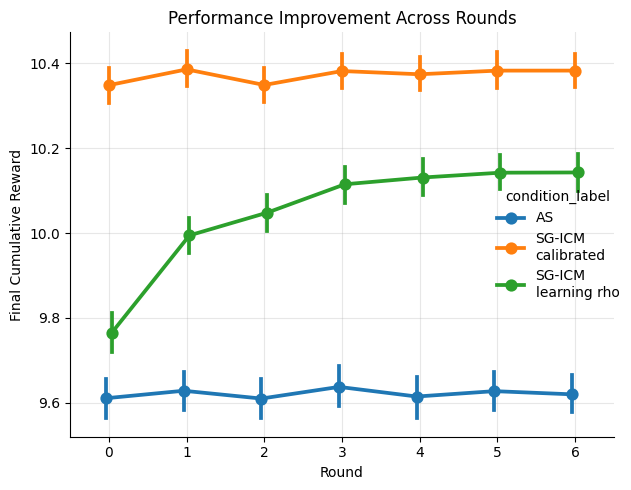

In [48]:
def _select_sg_agent(df):
    plot_df = df.copy()
    if "model_type" in plot_df.columns:
        sg = plot_df[(plot_df["model_type"] == "SG-ICM") | (plot_df["model_type"] == "SG")].copy()
        if not sg.empty:
            return sg
    if "AgentID" in plot_df.columns:
        min_id = plot_df["AgentID"].min()
        return plot_df[plot_df["AgentID"] == min_id].copy()
    return plot_df

# Plot Cumulative Reward Evolution across Rounds
def plot_learning_across_rounds(df):
    plot_df = _select_sg_agent(df)

    idx_max_step = plot_df.groupby(["seed", "Round", "condition_label"])["Step"].idxmax()
    summary = plot_df.loc[idx_max_step]

    plt.figure(figsize=(8, 5))
    sns.catplot(
        data=summary,
        x="Round",
        y="cumulative_reward",
        hue="condition_label",
        kind="point",
        dodge=True,
        legend=True
    )
    plt.title("Performance Improvement Across Rounds")
    plt.ylabel("Final Cumulative Reward")
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_learning_across_rounds(results)

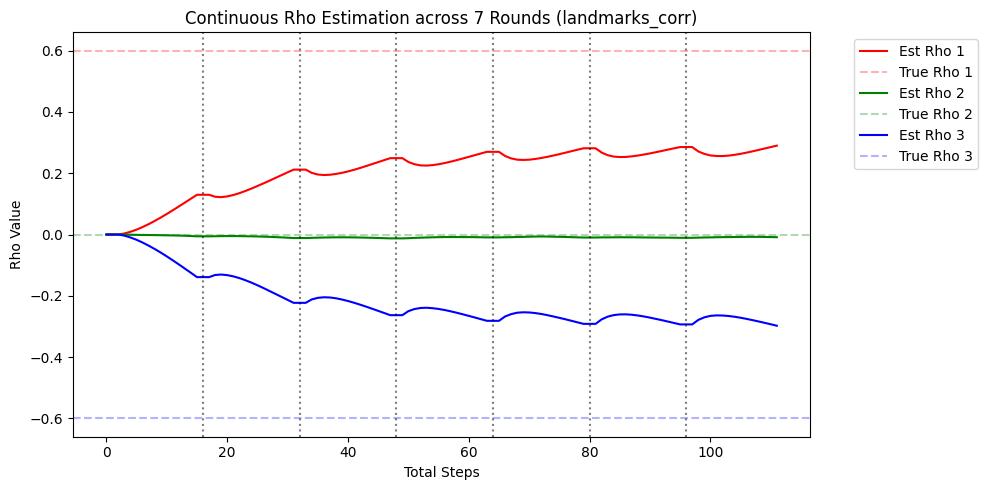

In [44]:
# Plot Rho Estimation Evolution (Stitching rounds together)
def plot_rho_longitudinal(target_condition="landmarks_corr"):
    """
     visualizes how the rho estimate evolves continuously across rounds
    """
    # Filter histories for the specific condition
    relevant_histories = [
        h for h in all_rho_histories
        if h["condition"] == target_condition
    ]

    if not relevant_histories:
        print(f"No history found for {target_condition}")
        return

    # Sort by seed and round
    relevant_histories.sort(key=lambda x: (x["seed"], x["round"]))

    max_seed = max(h['seed'] for h in relevant_histories)
    stitched_trajectories = []

    for s in range(max_seed + 1):
        seed_hists = [h["rho_history"] for h in relevant_histories if h["seed"] == s]
        if not seed_hists: continue
        stitched = np.concatenate(seed_hists, axis=0)
        stitched_trajectories.append(stitched)

    if not stitched_trajectories:
        return

    # Average across seeds
    # Stack: (n_seeds, total_steps, n_dims)
    # Note: total_steps = N_ROUNDS * (N_STEPS + 1) roughly
    min_len = min(len(t) for t in stitched_trajectories)
    trimmed_trajectories = [t[:min_len] for t in stitched_trajectories]
    avg_trajectory = np.mean(np.stack(trimmed_trajectories), axis=0)

    true_rhos = rho_true[1:] # peers only

    plt.figure(figsize=(10, 5))
    steps = np.arange(len(avg_trajectory))

    colors = ['r', 'g', 'b']
    for i in range(3): # 3 peers
        plt.plot(steps, avg_trajectory[:, i+1], label=f'Est Rho {i+1}', color=colors[i])
        plt.axhline(true_rhos[i], linestyle='--', color=colors[i], alpha=0.3, label=f'True Rho {i+1}')

    # Draw vertical lines for round boundaries
    steps_per_round = len(avg_trajectory) / N_ROUNDS
    for r in range(1, N_ROUNDS):
        plt.axvline(r * steps_per_round, color='k', linestyle=':', alpha=0.5)

    plt.title(f"Continuous Rho Estimation across {N_ROUNDS} Rounds ({target_condition})")
    plt.xlabel("Total Steps")
    plt.ylabel("Rho Value")

    # De-duplicate legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_rho_longitudinal("landmarks_corr")

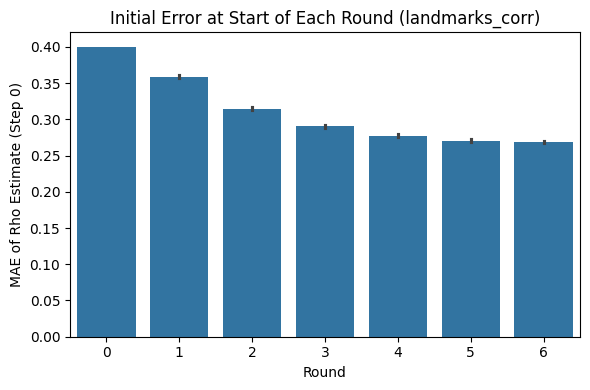

In [45]:
def plot_round_start_mae(target_condition="landmarks_corr"):
    relevant_histories = [
        h for h in all_rho_histories
        if h["condition"] == target_condition
    ]

    data = []
    for h in relevant_histories:
        start_rho = h["rho_history"][0, 1:] # Peers only
        true_r = rho_true[1:]
        mae = np.mean(np.abs(start_rho - true_r))
        data.append({
            "Round": h["round"],
            "Start_MAE": mae
        })

    df_mae = pd.DataFrame(data)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=df_mae, x="Round", y="Start_MAE", errorbar="ci")
    plt.title(f"Initial Error at Start of Each Round ({target_condition})")
    plt.ylabel("MAE of Rho Estimate (Step 0)")
    plt.xlabel("Round")
    plt.tight_layout()
    plt.show()

plot_round_start_mae()

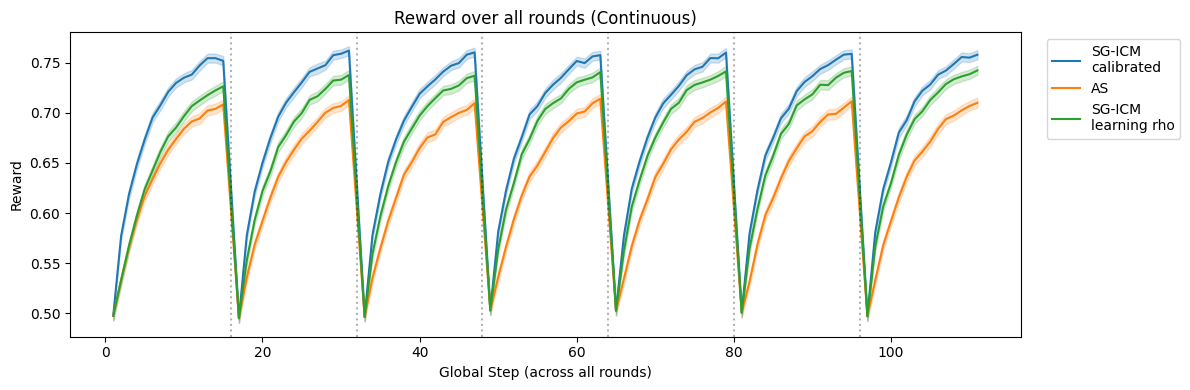

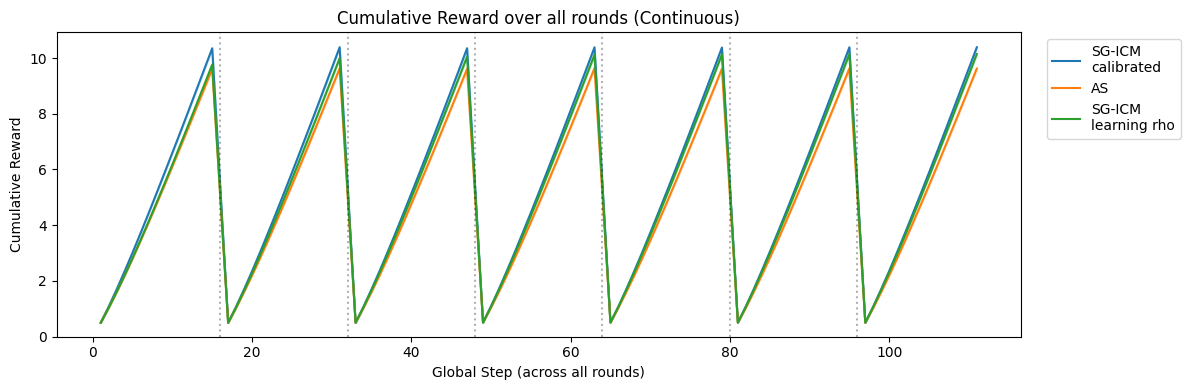

In [46]:
def plot_longitudinal_metric(df, y_col="reward", hue="condition_label"):
    """
    Plots a metric across all rounds stitched together (Global Step).
    """
    plot_df = _select_sg_agent(df).copy()

    steps_per_round = plot_df["Step"].max() + 1
    plot_df["GlobalStep"] = plot_df["Round"] * steps_per_round + plot_df["Step"]

    plt.figure(figsize=(12, 4))
    sns.lineplot(
        data=plot_df,
        x="GlobalStep",
        y=y_col,
        hue=hue,
        errorbar="ci"
    )

    # Add vertical lines for round boundaries
    max_round = plot_df["Round"].max()
    for r in range(1, max_round + 1):
        plt.axvline(r * steps_per_round, color='k', linestyle=':', alpha=0.3)

    plt.title(f"{y_col.replace('_', ' ').title()} over all rounds (Continuous)")
    plt.xlabel("Global Step (across all rounds)")
    plt.ylabel(y_col.replace('_', ' ').title())
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_longitudinal_metric(results, y_col="reward")
plot_longitudinal_metric(results, y_col="cumulative_reward")